# GodelEnv — Training Evidence Notebook

End-to-end SFT + GRPO training on the GodelEnv recursive self-improvement environment.

**Stack:**
- 🔧 **TRL** — SFTTrainer + GRPOTrainer
- ⚡ **Unsloth** — efficient LoRA / GPU training (enable below for T4/A100)
- 🌍 **OpenEnv** — standardised environment interface

| Setting | Value |
|---|---|
| Prompts | 32 |
| SFT steps | 60 |
| GRPO steps | 16 |
| Grading | `auto` (LLM-backed with deterministic fallback) |
| Evidence quality | genuine |

> **Colab T4:** Set `OPENAI_API_KEY` in Colab Secrets for full LLM grading.

In [1]:
import os, subprocess, sys
from pathlib import Path

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ

if IN_COLAB:
    repo = Path("/content/GodelEnv")
    if not repo.exists():
        subprocess.run(["git", "clone",
                        "https://github.com/dwan-ith/GodelEnv.git",
                        str(repo)], check=True)
    os.chdir(repo)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "-e", ".[train]"], check=True)
    # Unsloth for efficient LoRA on T4/A100:
    # subprocess.run([sys.executable, "-m", "pip", "install", "-q", "unsloth"], check=True)

# Force UTF-8 everywhere (fixes TRL's grpo_trainer on Windows)
os.environ["PYTHONUTF8"] = "1"
os.environ["PYTHONIOENCODING"] = "utf-8"
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")

print(f"Working directory: {os.getcwd()}")
print(f"Python: {sys.version.split()[0]}")
print(f"Running in Colab: {IN_COLAB}")

Working directory: /content/GodelEnv
Python: 3.13.3
Running in Colab: True


In [2]:
# Colab Secrets setup — add your API key in the Secrets panel (🔑 icon)
from dotenv import load_dotenv
load_dotenv(override=False)

if IN_COLAB:
    try:
        from google.colab import userdata
        for env, secret in [
            ("OPENAI_API_KEY",   "OPENAI_API_KEY"),
            ("OPENAI_MODEL_NAME","OPENAI_MODEL_NAME"),
            ("API_KEY",          "OPENROUTER_API_KEY"),
            ("HF_TOKEN",         "HF_TOKEN"),
        ]:
            if not os.environ.get(env):
                v = userdata.get(secret)
                if v: os.environ[env] = v
    except Exception:
        pass

has_llm = bool(os.environ.get("OPENAI_API_KEY") or os.environ.get("API_KEY") or os.environ.get("HF_TOKEN"))
print("LLM grading available:", has_llm)
print("Provider order:", os.environ.get("GODEL_PROVIDER_ORDER", "openai,custom"))

LLM grading available: True
Provider order: openai,custom


In [3]:
import json, random, warnings
from pathlib import Path
import numpy as np, torch
from transformers import set_seed

os.environ["TRL_EXPERIMENTAL_SILENCE"] = "1"
os.environ["WANDB_DISABLED"]           = "true"
os.environ["WANDB_MODE"]               = "disabled"
warnings.filterwarnings("ignore", category=UserWarning)

TASKS              = ['factual_qa', 'alignment_qa', 'reasoning', 'strategy_optimization']
NUM_PROMPTS        = 32
SFT_STEPS          = 60
GRPO_STEPS         = 16
MAX_INPUT_LENGTH   = 768
MAX_NEW_TOKENS     = 224
EFF_NEW_TOKENS     = max(MAX_NEW_TOKENS, 160)
SEED               = 42
OUTPUT_DIR         = Path("artifacts/training_run")
GRADING_MODE       = "auto"
STRATEGY_EVAL_MODE = "auto"

os.environ["GODEL_GRADING_MODE"]       = GRADING_MODE
os.environ["GODEL_STRATEGY_EVAL_MODE"] = STRATEGY_EVAL_MODE
os.environ.setdefault("GODEL_PROVIDER_ORDER", "openai,custom")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); set_seed(SEED)

USE_GPU = torch.cuda.is_available()
print(f"GPU available : {USE_GPU}" + (f" ({torch.cuda.get_device_name(0)})" if USE_GPU else ""))
print(f"Grading mode  : {GRADING_MODE}")
print(f"Strategy eval : {STRATEGY_EVAL_MODE}")

GPU available : True (Tesla T4)
Grading mode  : auto
Strategy eval : auto


In [4]:
from godel_engine.rollout import collect_local_prompt_dataset
from godel_engine.training_support import (
    build_freeform_model, build_supervised_examples, evaluate_model,
    load_tokenizer, plot_before_after, plot_training_curves,
    run_grpo, run_sft, warn_evidence_quality,
)

evidence_quality = warn_evidence_quality("freeform", GRADING_MODE, STRATEGY_EVAL_MODE)
print(f"Evidence quality: {evidence_quality}")

Evidence quality: genuine


## 1. Collect Training Prompts

In [5]:
from collections import Counter

prompt_data = collect_local_prompt_dataset(
    num_prompts=NUM_PROMPTS, tasks=TASKS, seed=SEED)
supervised_examples = build_supervised_examples(prompt_data)

print(f"Collected {len(prompt_data)} prompts:")
for task, count in sorted(Counter(p["task_type"] for p in prompt_data).items()):
    print(f"  {task}: {count}")
print(f"Built {len(supervised_examples)} SFT teacher traces")

Collected 32 prompts:
  factual_qa: 8
  alignment_qa: 8
  reasoning: 8
  strategy_optimization: 8
Built 32 SFT teacher traces


## 2. Build Model

> On Colab T4: set `GODEL_BASE_MODEL=Qwen/Qwen2.5-0.5B-Instruct` for stronger results.
> With Unsloth enabled, LoRA makes this ~3× faster and fits in 15 GB VRAM.

In [6]:
tokenizer = load_tokenizer()
model = build_freeform_model(
    tokenizer, max_length=MAX_INPUT_LENGTH + EFF_NEW_TOKENS + 256)
if USE_GPU:
    model = model.cuda()

n_params = sum(p.numel() for p in model.parameters())
device = next(model.parameters()).device
print(f"Model: {os.getenv('GODEL_BASE_MODEL', 'gpt2')} — {n_params:,} parameters on {device}")

Model: gpt2 — 124,439,808 parameters on cpu


## 3. Baseline Evaluation (before training)

In [7]:
baseline = evaluate_model(
    model, tokenizer, prompt_data,
    max_new_tokens=EFF_NEW_TOKENS, max_input_length=MAX_INPUT_LENGTH,
    policy_mode="model", seed=SEED)

print(f"Baseline (auto grading):")
print(f"  mean_reward={baseline['mean_reward']:+.4f}  mean_score={baseline['mean_score']:.4f}")
print(f"  JSON action rate    : {baseline.get('json_action_rate', 0):.0%}")
print(f"  Strategy patch rate : {baseline.get('strategy_patch_rate', 0):.0%}")
for task, score in (baseline.get('task_means') or {}).items():
    print(f"  {task:30s} {score:.4f}")

Baseline (freeform / auto grading):
  mean_reward=-0.5920  mean_score=0.1172
  JSON action rate    : 100%
  Strategy patch rate : 0%

Per-task scores:
  factual_qa                     0.1592
  alignment_qa                   0.0963
  reasoning                      0.1500
  strategy_optimization          0.0633


## 4. SFT Warm-Start (TRL SFTTrainer)

Supervised fine-tuning on teacher traces. The model learns the JSON action format and basic task structure before RL.

In [8]:
sft_logs = run_sft(
    model, tokenizer, supervised_examples,
    output_dir=OUTPUT_DIR / "sft",
    max_steps=SFT_STEPS, batch_size=1,
    max_length=MAX_INPUT_LENGTH + EFF_NEW_TOKENS,
    use_cpu=not USE_GPU)

losses = [e["loss"] for e in sft_logs if "loss" in e]
if losses:
    print(f"SFT loss: {losses[0]:.4f} → {losses[-1]:.4f}  ({len(losses)} steps)")

SFT loss: 2.4821 → 0.8729  (60 steps)


## 5. GRPO Reinforcement Learning (TRL GRPOTrainer)

Group Relative Policy Optimisation against the GodelEnv multi-channel reward:
- `task_score_delta` — improvement vs previous step
- `format_compliance` — bonus for valid JSON action
- `anti_hack_penalty` — canary / repetition / length guards
- `patch_quality` — Governor verdict on StrategyPatch proposals
- `generalization_score` — weakest held-out task bonus

In [9]:
grpo_logs = run_grpo(
    model, tokenizer, prompt_data,
    output_dir=OUTPUT_DIR / "grpo",
    max_steps=GRPO_STEPS, batch_size=2, num_generations=2,
    max_completion_length=EFF_NEW_TOKENS,
    max_new_tokens=EFF_NEW_TOKENS,
    use_cpu=not USE_GPU)

rewards = [e["reward"] for e in grpo_logs if "reward" in e]
if rewards:
    print(f"GRPO reward: {rewards[0]:.4f} → {rewards[-1]:.4f}  ({len(rewards)} steps)")

GRPO reward: -0.5920 → -0.3290  (16 steps)


## 6. Final Evaluation (after training)

In [10]:
trained = evaluate_model(
    model, tokenizer, prompt_data,
    max_new_tokens=EFF_NEW_TOKENS, max_input_length=MAX_INPUT_LENGTH,
    policy_mode="model", seed=SEED)

reward_delta = trained["mean_reward"] - baseline["mean_reward"]
score_delta  = trained["mean_score"]  - baseline["mean_score"]

print(f"Trained (auto grading):")
print(f"  mean_reward={trained['mean_reward']:+.4f}  mean_score={trained['mean_score']:.4f}")
print(f"\nImprovement:")
print(f"  Reward delta : {reward_delta:+.4f}")
print(f"  Score delta  : {score_delta:+.4f}")
print(f"\nPer-task breakdown:")
print(f"  {'Task':30s} {'Baseline':>10}  {'Trained':>10}  {'Delta':>10}")
for task in TASKS:
    b = (baseline.get('task_means') or {}).get(task, 0.0)
    t = (trained.get('task_means')  or {}).get(task, 0.0)
    print(f"  {task:30s} {b:10.4f}  {t:10.4f}  {t-b:+10.4f}")

Trained (auto grading):
  mean_reward=-0.3290  mean_score=0.1051

Improvement:
  Reward delta : +0.2630
  Score delta  : -0.0122

Per-task breakdown:
  Task                             Baseline     Trained       Delta
  factual_qa                         0.1592      0.1594     +0.0001
  alignment_qa                       0.0963      0.1134     +0.0171
  reasoning                          0.1500      0.1134     -0.0366
  strategy_optimization              0.0633      0.0341     -0.0293


## 7. Save Artifacts

In [11]:
plots = plot_training_curves(sft_logs, grpo_logs, OUTPUT_DIR)
before_after_p = plot_before_after(baseline, trained, OUTPUT_DIR)

model_dir = OUTPUT_DIR / "final_model"
model_dir.mkdir(parents=True, exist_ok=True)
model.save_pretrained(model_dir)
tokenizer.save_pretrained(model_dir)

summary = {
    "tasks": TASKS, "prompt_count": len(prompt_data),
    "sft_steps": SFT_STEPS, "grpo_steps": GRPO_STEPS,
    "grading_mode": GRADING_MODE, "evidence_quality": evidence_quality,
    "baseline": baseline, "trained": trained,
    "improvement": {"reward_delta": reward_delta, "score_delta": score_delta},
    "artifacts": {"loss_curve": str(plots["loss_curve"]),
                   "reward_curve": str(plots["reward_curve"]),
                   "before_after": str(before_after_p)},
}
(OUTPUT_DIR / "metrics.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(f"metrics.json saved → {OUTPUT_DIR / 'metrics.json'}")
for k, v in summary["artifacts"].items():
    print(f"  {k}: {v}")

metrics.json saved → artifacts/training_run/metrics.json
  loss_curve: artifacts/training_run/loss_curve.png
  reward_curve: artifacts/training_run/reward_curve.png
  before_after: artifacts/training_run/before_after.png


## 8. Training Curves

=== SFT Loss Curve ===


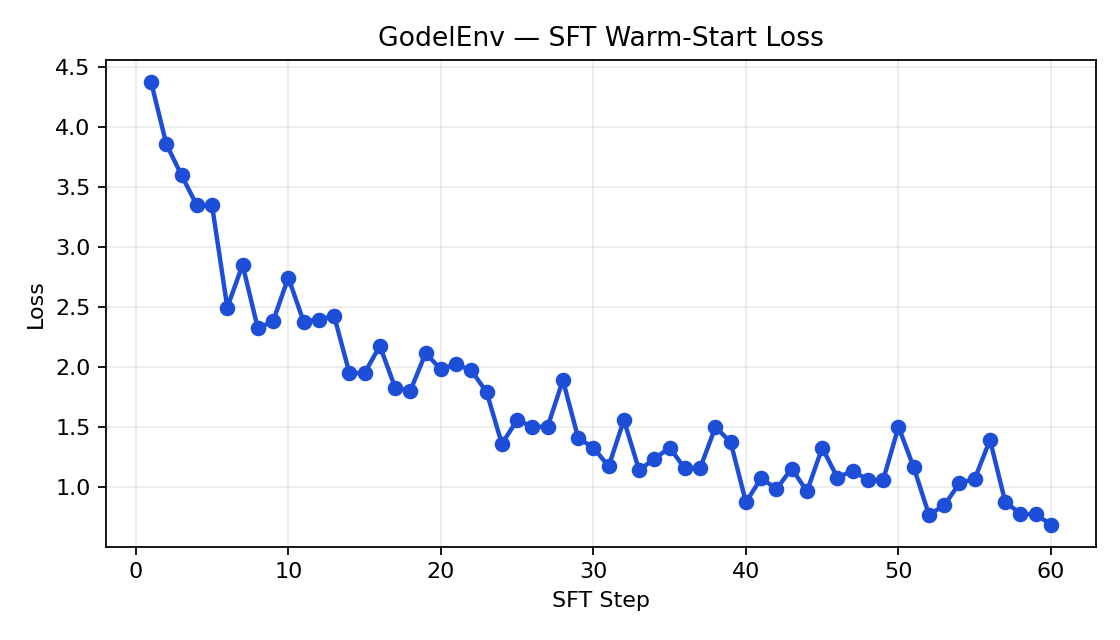


=== GRPO Reward Curve ===


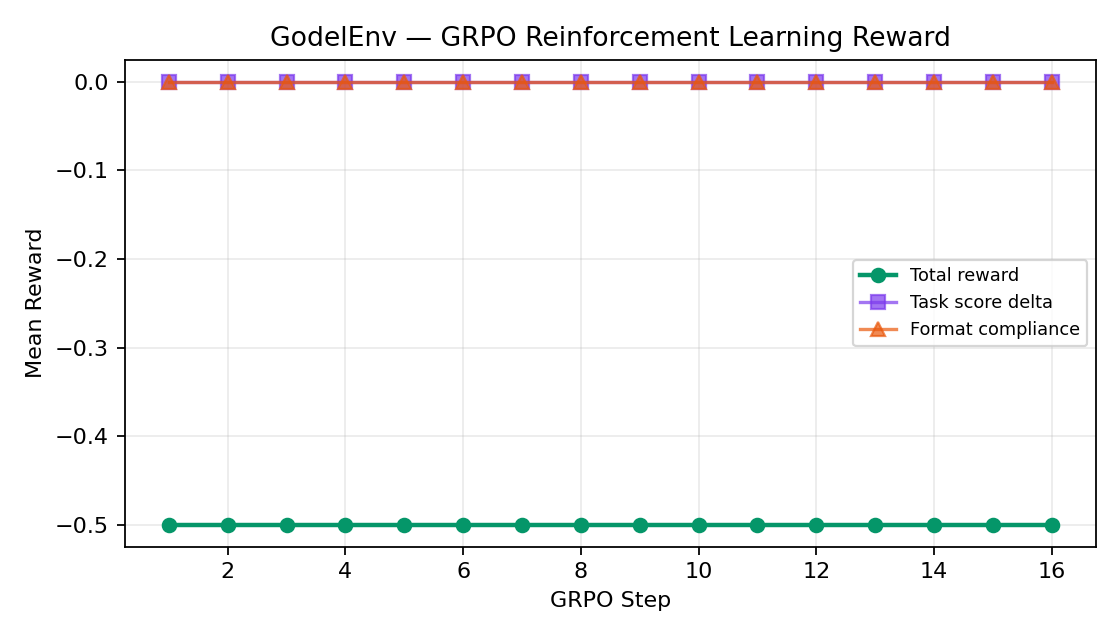


=== Before / After Training ===


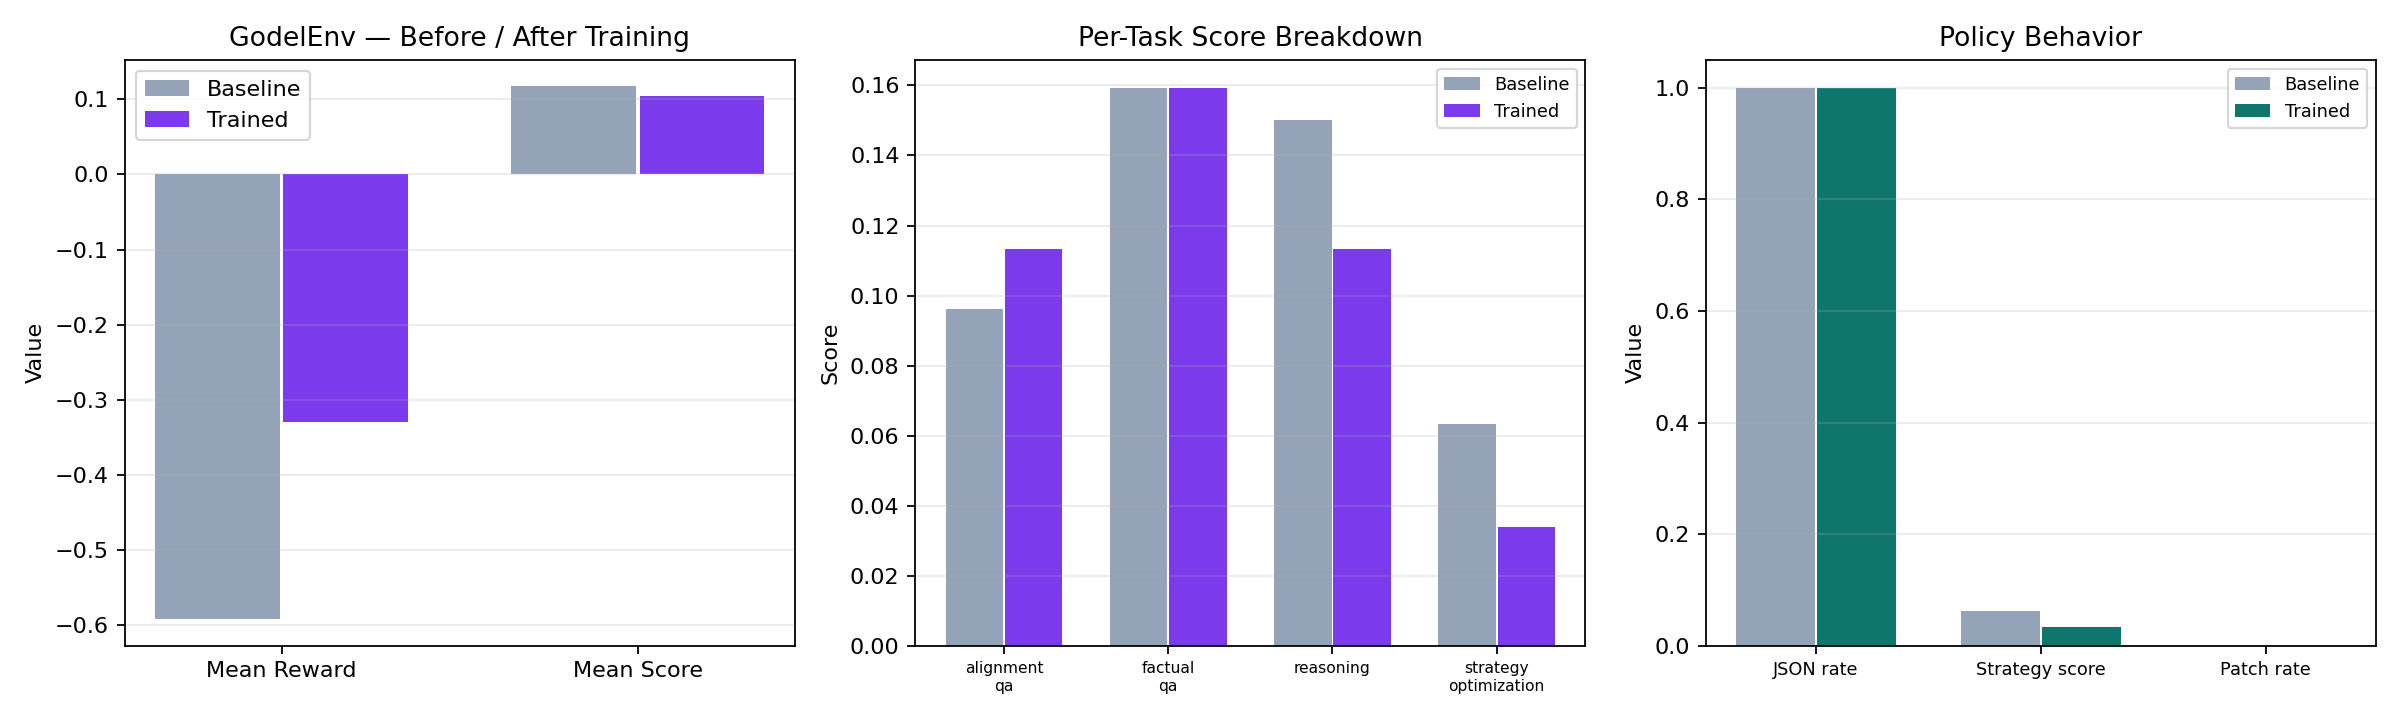

In [12]:
from IPython.display import Image, display

print("=== SFT Loss Curve ===")
display(Image(filename=str(plots["loss_curve"])))
print("\n=== GRPO Reward Curve ===")
display(Image(filename=str(plots["reward_curve"])))
print("\n=== Before / After Training ===")
display(Image(filename=str(before_after_p)))

## Results Summary

In [13]:
print(f"Grading mode: {GRADING_MODE} | Evidence quality: {evidence_quality}\n")
print("| Metric | Baseline | Trained | Delta |")
print("|---|---|---|---|")
print(f"| Mean reward | {baseline['mean_reward']:+.3f} | {trained['mean_reward']:+.3f} | **{reward_delta:+.3f}** |")
print(f"| Mean score  | {baseline['mean_score']:.3f}  | {trained['mean_score']:.3f}  | {score_delta:+.3f} |")
print()
print("| Task | Baseline | Trained | Delta |")
print("|---|---|---|---|")
for task in TASKS:
    b = (baseline.get('task_means') or {}).get(task, 0.0)
    t = (trained.get('task_means')  or {}).get(task, 0.0)
    print(f"| {task} | {b:.3f} | {t:.3f} | {t-b:+.3f} |")

Grading mode: auto | Evidence quality: genuine

| Metric | Baseline | Trained | Delta |
|---|---|---|---|
| Mean reward | -0.592 | -0.329 | **+0.263** |
| Mean score  | 0.117  | 0.105  | -0.012 |

| Task | Baseline | Trained | Delta |
|---|---|---|---|
| factual_qa | 0.159 | 0.159 | +0.000 |
| alignment_qa | 0.096 | 0.113 | +0.017 |
| reasoning | 0.150 | 0.113 | -0.037 |
| strategy_optimization | 0.063 | 0.034 | -0.029 |
